# Modell um defekte Flaschen zu erkennen

import der Libraries

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


import the drop oszillation data from database

In [66]:
import sys
import os
import json
#sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
from database.database import Database 

db = Database('db.json') 
drop_osz = db.get_by_topic('iot1/teaching_factory/drop_oscillation')
#print(drop_osz)
truth= db.get_by_topic('iot1/teaching_factory/ground_truth')
#print(truth)
# Erstelle eine Liste von Dictionaries mit bottle, oszillation und is_cracked
data = []
for drop, gt in zip(drop_osz, truth):
    drop_payload = json.loads(drop['payload'])
    gt_payload = json.loads(gt['payload'])
    data.append({
        'bottle': drop_payload['bottle'],
        'oszillation': [float(x) for x in drop_payload['drop_oscillation']],
        'is_cracked': int(gt_payload['is_cracked'])
    })

df = pd.DataFrame(data)
print(df.head())





     bottle                                        oszillation  is_cracked
0  49029009  [-0.0, -0.0155132089, 0.0042205726, 0.07253360...           0
1  49029011  [0.0, -0.1117576092, 0.0899792412, 0.167785483...           0
2  49029013  [0.0, 0.5958697312, 0.9473750736, 1.3957533734...           0
3  49029511  [0.0, 0.5713077815, 0.7623014814, 0.9734101524...           0
4  49029513  [-0.0, -0.0245419871, -0.042227983, -0.0267830...           0


Plot of a sample bottle that is  not cracked

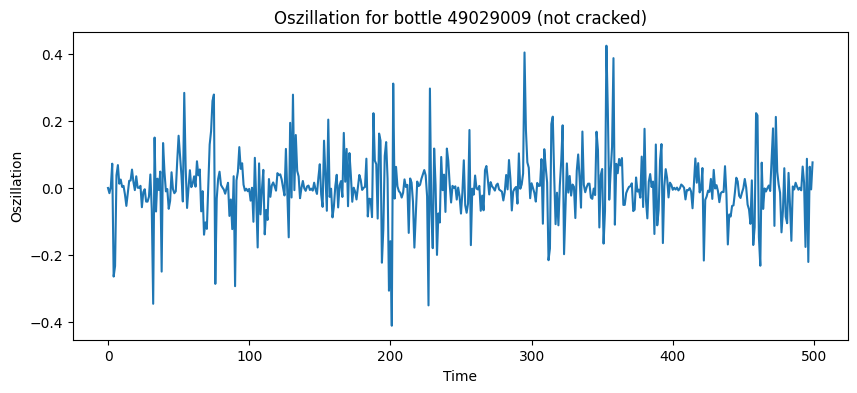

In [67]:
# Select a sample bottle that is not cracked
sample = df[df['is_cracked'] == 0].iloc[0]
oszillation = sample['oszillation']

plt.figure(figsize=(10, 4))
plt.plot(oszillation)
plt.title(f"Oszillation for bottle {sample['bottle']} (not cracked)")
plt.xlabel("Time")
plt.ylabel("Oszillation")
plt.show()

Plot of a sample bottle thas is cracked

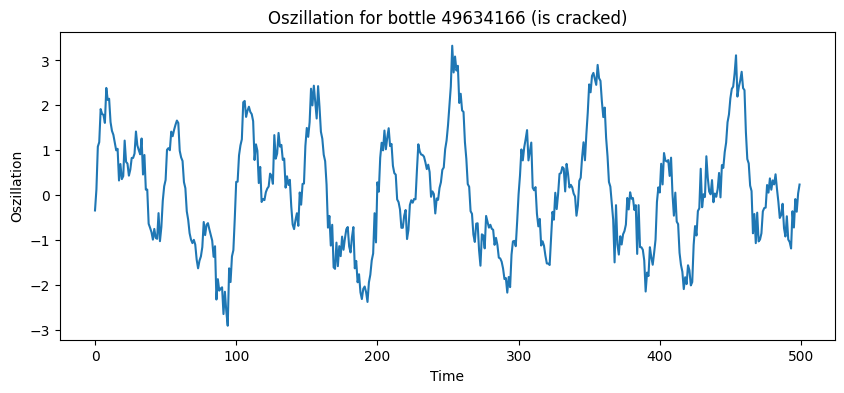

In [68]:
# Select a sample bottle that is is cracked
sample = df[df['is_cracked'] == 1].iloc[0]
oszillation = sample['oszillation']

plt.figure(figsize=(10, 4))
plt.plot(oszillation)
plt.title(f"Oszillation for bottle {sample['bottle']} (is cracked)")
plt.xlabel("Time")
plt.ylabel("Oszillation")
plt.show()

Feature engineering to extract relevant features from the oscillation data

In [69]:
# Feature engineering: calculate mean, max, min, std for each bottle's oszillation
df['osz_mean'] = df['oszillation'].apply(np.mean)
df['osz_max'] = df['oszillation'].apply(np.max)
df['osz_min'] = df['oszillation'].apply(np.min)
df['osz_std'] = df['oszillation'].apply(np.std)
for i in range(1, 10):
    df[f"Freq_{i}"] = df["oszillation"].apply(lambda x: np.abs(np.fft.fft(x))[i])


df.head()



,bottle,oszillation,is_cracked,osz_mean,osz_max,osz_min,osz_std,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9
0,49029009,"[-0.0, -0.0155132089, 0.0042205726, 0.07253360...",0,0.002024,0.424665,-0.411182,0.095743,1.706290,4.154090,1.879419,1.319361,2.631853,1.175062,2.170946,1.898139,3.352154
1,49029011,"[0.0, -0.1117576092, 0.0899792412, 0.167785483...",0,0.015183,0.855454,-0.816893,0.229867,4.774136,2.479044,1.619633,2.065840,3.057927,2.833118,3.832911,2.602316,2.695396
2,49029013,"[0.0, 0.5958697312, 0.9473750736, 1.3957533734...",0,-0.025980,3.259212,-3.324974,1.386686,21.091366,16.507930,11.967995,355.993040,45.754546,111.636568,65.145665,32.863071,24.504365
3,49029511,"[0.0, 0.5713077815, 0.7623014814, 0.9734101524...",0,0.053596,2.264077,-2.520379,1.016645,31.559866,43.128815,55.871035,132.554688,171.926604,60.340262,97.407380,14.581159,8.462091
4,49029513,"[-0.0, -0.0245419871, -0.042227983, -0.0267830...",0,0.006470,0.638061,-0.570971,0.122292,3.860135,1.381438,4.036607,1.205848,5.444958,2.297783,1.386624,4.332389,1.166038


Data splitting into training and test sets

In [70]:
y = df['is_cracked']
X = df.drop(['bottle','is_cracked','oszillation'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Logistic Regression Model

Train logistic regression model on the training set

In [71]:
model_log = LogisticRegression(max_iter=100000)

model_log.fit(X_train, y_train)

model_log.coef_

array([[ 0.03258367,  1.43874793, -1.24447418,  0.39709952, -0.20067632,
         0.25379487,  0.19231641, -0.01205361, -0.0100607 ,  0.07744611,
        -0.64150896, -0.02472153, -0.07718257]])

Make predictions on the train set

In [72]:
y_pred = model_log.predict(X_train)

Confusion matrix to evaluate the model performance on the train set

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        92
           1       1.00      0.88      0.93         8

    accuracy                           0.99       100
   macro avg       0.99      0.94      0.96       100
weighted avg       0.99      0.99      0.99       100



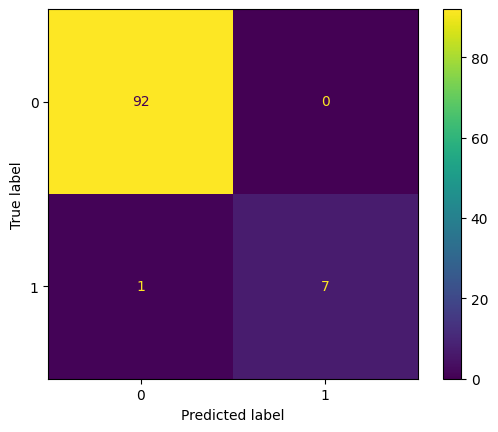

In [73]:
cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,)

disp.plot()
print(classification_report(y_train, y_pred))

Confusion matrix to evaluate the model performance on the test set

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.67      0.80         3

    accuracy                           0.96        25
   macro avg       0.98      0.83      0.89        25
weighted avg       0.96      0.96      0.96        25



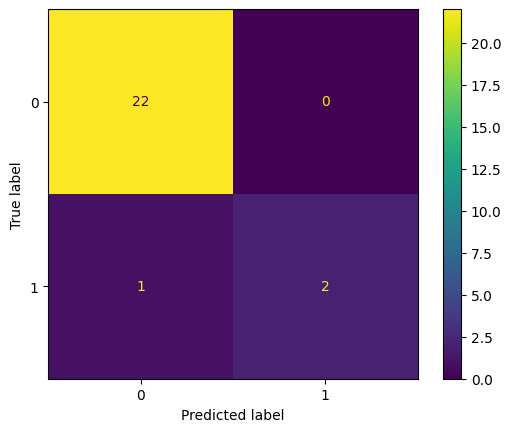

In [74]:
y_pred = model_log.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
print(classification_report(y_test, y_pred))

## Logistic regression model without fourier features

Train logistic regression model on the training set

In [75]:
y = df['is_cracked']
X = df[['osz_mean', 'osz_max', 'osz_min', 'osz_std']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Train logistic regression model on the training set

In [76]:
model_log_simple = LogisticRegression(max_iter=100000)

model_log_simple.fit(X_train, y_train)

model_log_simple.coef_

array([[ 0.21105371,  0.25303095, -0.78014781, -0.6651704 ]])

Make predictions on the train set

In [77]:
y_pred = model_log_simple.predict(X_train)

Confusion matrix to evaluate the model performance on the train set

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        92
           1       0.00      0.00      0.00         8

    accuracy                           0.92       100
   macro avg       0.46      0.50      0.48       100
weighted avg       0.85      0.92      0.88       100



c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being se

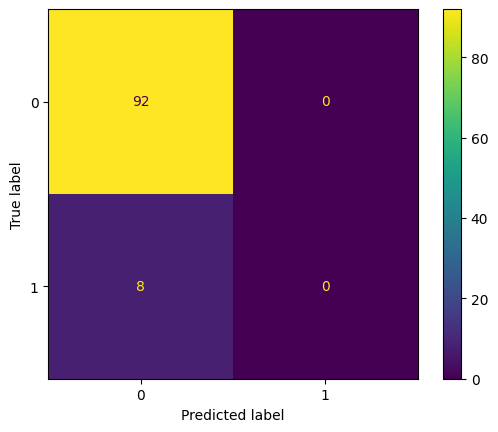

In [78]:
cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,)

disp.plot()
print(classification_report(y_train, y_pred))

Confusion matrix to evaluate the model performance on the test set

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       0.00      0.00      0.00         3

    accuracy                           0.88        25
   macro avg       0.44      0.50      0.47        25
weighted avg       0.77      0.88      0.82        25



c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manuh\Documents\Drive\4.Sem_Mechatronik_Laptop\Automatisierungstechnik\AUT_IOT\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being se

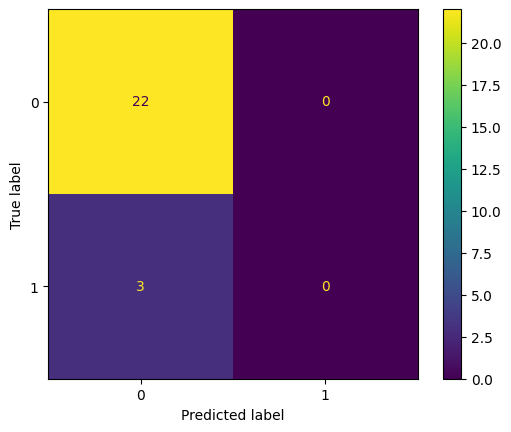

In [79]:
y_pred = model_log_simple.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
print(classification_report(y_test, y_pred))